# Repo Stats — AI Bloat Edition

Looks for fingerprints of AI-generated code drift:

- **Total lines over time** (anchored on real working-tree count)
- **Per-language growth** — which file types are exploding
- **Commit size distribution** — AI tends to drop huge batched changes
- **Average lines added per commit, over time** — rising = vibes
- **Hot files** — repeat-offender files that keep ballooning
- **Comment density (current tree)** — over-commented files are a tell
- **Test / docs ratio over time** — AI loves writing both

Run from the repo root.  Adjust `SINCE`, `BUCKET`, and `PATHSPEC` in the next cell.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────
SINCE       = None            # e.g. "1 year ago"; None = all history
BUCKET      = "week"          # day | week | month
PATHSPEC    = []              # e.g. ["packages/**", ":!**/*.lock"]
TOP_N_FILES = 25
COMMIT_ROLL = 50              # rolling-window size (# commits) for "over commits" mode

import os
import subprocess
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider

# Anchor at the repo root so `git ls-files` and file reads work regardless
# of where JupyterLab was launched (notebook lives in scripts/).
REPO_ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
os.chdir(REPO_ROOT)
print(f"Working from: {REPO_ROOT}")

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 100})

BUCKETS = {"day": "D", "week": "W-MON", "month": "MS"}
FREQ    = BUCKETS[BUCKET]

# Map file extensions → language label.  Anything unmapped falls under "other".
LANG_BY_EXT = {
    ".py": "python",
    ".ts": "ts", ".tsx": "ts",
    ".js": "js", ".jsx": "js", ".mjs": "js",
    ".go": "go",
    ".rs": "rust",
    ".md": "markdown",
    ".yaml": "yaml", ".yml": "yaml",
    ".json": "json",
    ".sh": "shell", ".bash": "shell", ".zsh": "shell",
    ".sql": "sql",
    ".html": "web", ".css": "web", ".scss": "web",
    ".toml": "config", ".ini": "config", ".cfg": "config",
    ".dockerfile": "docker",
}

def lang_for(path: str) -> str:
    p = path.lower()
    if p.endswith("dockerfile") or "/dockerfile" in p or p == "dockerfile":
        return "docker"
    return LANG_BY_EXT.get(Path(p).suffix, "other")


def _format_x_axis(ax, x_mode: str):
    """Apply matplotlib formatting appropriate to the x-axis mode."""
    if x_mode == "time":
        loc = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(loc)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
        ax.set_xlabel("")
    else:
        ax.set_xlabel("commit # (chronological)")

## 1. Pull `git log --numstat` into a dataframe

In [ ]:
def git_log(since, pathspec):
    cmd = ["git", "log", "--numstat", "--date=short", "--no-merges",
           "--pretty=format:COMMIT|%H|%ad|%an|%s"]
    if since:
        cmd.append(f"--since={since}")
    if pathspec:
        cmd.append("--")
        cmd.extend(pathspec)
    return subprocess.run(cmd, capture_output=True, text=True, check=True).stdout

def parse(raw):
    rows = []
    sha = author = subject = None
    dt = None
    for line in raw.splitlines():
        if not line.strip():
            continue
        if line.startswith("COMMIT|"):
            _, sha, datestr, author, subject = line.split("|", 4)
            dt = datetime.strptime(datestr, "%Y-%m-%d").date()
            continue
        parts = line.split("\t")
        if len(parts) < 3 or dt is None:
            continue
        a, r, path = parts[0], parts[1], parts[2]
        if a == "-" or r == "-":
            continue
        try:
            rows.append((dt, int(a), int(r), sha, author, subject, path, lang_for(path)))
        except ValueError:
            continue
    df = pd.DataFrame(rows, columns=["date","added","removed","sha","author","subject","path","lang"])
    df["date"] = pd.to_datetime(df["date"])
    df["net"]  = df["added"] - df["removed"]

    # Chronological commit index (oldest = 0). Stable tie-break on first appearance order.
    commit_order = (df.groupby("sha", sort=False)["date"].first()
                      .sort_values(kind="stable"))
    commit_idx_map = {sha: i for i, sha in enumerate(commit_order.index)}
    df["commit_idx"] = df["sha"].map(commit_idx_map)
    return df

df = parse(git_log(SINCE, PATHSPEC))
print(f"{df['sha'].nunique():,} commits, {len(df):,} file-changes")
print(f"{df['date'].min().date()} → {df['date'].max().date()}")
print(f"+{df['added'].sum():,}  -{df['removed'].sum():,}  net {df['net'].sum():+,}")
df.head()

## 2. Total lines over time

Anchored on the **actual working-tree line count** (not just cumulative net), so the right edge equals reality.

In [52]:
def current_lines_per_lang():
    files = subprocess.run(["git", "ls-files", "-z"], capture_output=True, check=True).stdout.split(b"\x00")
    totals = defaultdict(int)
    for fb in files:
        if not fb:
            continue
        path = fb.decode("utf-8", errors="replace")
        try:
            with open(path, "rb") as fh:
                n = sum(1 for _ in fh)
        except (OSError, IsADirectoryError):
            continue
        totals[lang_for(path)] += n
    return dict(totals)

current_by_lang = current_lines_per_lang()
current_total   = sum(current_by_lang.values())
print(f"Current working-tree line count: {current_total:,}")
pd.Series(current_by_lang).sort_values(ascending=False)

Current working-tree line count: 95,348


python      43793
json        11999
ts          11897
markdown     9535
other        8439
yaml         7416
shell         731
web           602
docker        489
config        418
js             29
dtype: int64

In [ ]:
def is_fixture(path: str) -> bool:
  p = path.lower()
  name = Path(p).name
  stem = Path(p).stem

  return (
    p.startswith("fixtures/")
    or "/fixtures/" in p
    or p.startswith("__fixtures__/")
    or "/__fixtures__/" in p
    or p.startswith("testdata/")
    or "/testdata/" in p
    or p.startswith("test-data/")
    or "/test-data/" in p
    or name.endswith(".fixture.json")
    or name.endswith(".fixture.yaml")
    or name.endswith(".fixture.yml")
    or name.endswith(".fixture.txt")
    or stem.endswith("_fixture")
  )

def is_test(path: str) -> bool:
  if is_fixture(path):
    return False

  p = path.lower()
  name = Path(p).name

  return (
    p.startswith("tests/")
    or "/tests/" in p
    or p.startswith("test/")
    or "/test/" in p
    or name.startswith("test_")
    or name.endswith("_test.py")
    or name.endswith("_spec.py")
    or p.endswith("_test.go")
    or p.endswith(".test.ts")
    or p.endswith(".test.tsx")
    or p.endswith(".spec.ts")
    or p.endswith(".spec.tsx")
    or p.endswith(".spec.js")
    or p.endswith(".spec.jsx")
  )

def line_bucket_for_path(path: str) -> str:
  if is_fixture(path):
    return "fixtures"
  if is_test(path):
    return "tests"
  return "code"

def current_line_counts_by_bucket() -> dict[str, int]:
  tracked_files = files if "files" in globals() else subprocess.run(
    ["git", "ls-files", "-z"], capture_output=True, check=True
  ).stdout.split(b"\x00")

  totals = {"code": 0, "tests": 0, "fixtures": 0}
  for fb in tracked_files:
    if not fb:
      continue
    path = fb.decode("utf-8", errors="replace")
    bucket = line_bucket_for_path(path)
    try:
      with open(path, "rb") as fh:
        totals[bucket] += sum(1 for _ in fh)
    except (OSError, IsADirectoryError):
      continue
  return totals

df["line_bucket"] = df["path"].map(line_bucket_for_path)
current_by_bucket = current_line_counts_by_bucket()


def _bucket_totals_by_mode(x_mode: str) -> pd.DataFrame:
    if x_mode == "time":
        bucket_net = (
            df.set_index("date")
              .groupby("line_bucket")["net"]
              .resample(FREQ).sum()
              .unstack(level=0).fillna(0)
        )
    else:
        bucket_net = (
            df.groupby(["commit_idx", "line_bucket"])["net"]
              .sum()
              .unstack("line_bucket").fillna(0)
              .sort_index()
        )

    totals = pd.DataFrame(index=bucket_net.index)
    for bucket in ["code", "tests", "fixtures"]:
        series = bucket_net[bucket] if bucket in bucket_net.columns else pd.Series(0, index=bucket_net.index)
        after = series[::-1].cumsum()[::-1] - series
        totals[bucket] = current_by_bucket.get(bucket, 0) - after
    return totals.fillna(0).clip(lower=0)


def plot_bucket_totals(x_mode="time"):
    totals = _bucket_totals_by_mode(x_mode)
    fig, ax = plt.subplots(figsize=(13, 5))
    colors = {"code": "#16a085", "tests": "#3498db", "fixtures": "#8e44ad"}
    for bucket in ["code", "tests", "fixtures"]:
        ax.plot(totals.index, totals[bucket], linewidth=2.2,
                color=colors[bucket],
                label=f"{bucket} ({current_by_bucket[bucket]:,})")
    ax.set_title(f"Total lines over {x_mode} — code vs tests vs fixtures", fontsize=13)
    ax.set_ylabel("lines")
    _format_x_axis(ax, x_mode)
    ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()


interact(plot_bucket_totals,
         x_mode=Dropdown(options=["time", "commits"], value="time", description="X-axis"))

pd.Series(current_by_bucket, name="current_lines").to_frame()

## 3. Per-language growth (stacked)

Same back-derivation as above, applied per language.  Spotting which language is bloating helps localize where AI churn lives.

In [ ]:
def _lang_totals_by_mode(x_mode: str) -> pd.DataFrame:
    if x_mode == "time":
        lang_net = (df.set_index("date").groupby("lang")["net"]
                      .resample(FREQ).sum().unstack(level=0).fillna(0))
    else:
        lang_net = (df.groupby(["commit_idx", "lang"])["net"]
                      .sum().unstack("lang").fillna(0).sort_index())

    totals = pd.DataFrame(index=lang_net.index)
    for lang in lang_net.columns:
        series = lang_net[lang]
        after = series[::-1].cumsum()[::-1] - series
        totals[lang] = current_by_lang.get(lang, 0) - after
    return totals


def plot_lang_growth(x_mode="time"):
    lang_totals = _lang_totals_by_mode(x_mode)
    keep = sorted(
        [c for c in lang_totals.columns if current_by_lang.get(c, 0) >= 200],
        key=lambda c: -current_by_lang.get(c, 0),
    )
    lt = lang_totals[keep].clip(lower=0)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.stackplot(lt.index, lt.T.values, labels=keep, alpha=0.85)
    ax.set_title(f"Total lines over {x_mode}, by language", fontsize=13)
    ax.set_ylabel("lines")
    ax.legend(loc="upper left", fontsize=9, ncols=2)
    _format_x_axis(ax, x_mode)
    fig.tight_layout()
    plt.show()


interact(plot_lang_growth,
         x_mode=Dropdown(options=["time", "commits"], value="time", description="X-axis"))

## 4. Commit size distribution

Human commits cluster small (<100 lines).  AI-driven commits often spike into the thousands.  The dashed lines mark p50 / p90 / p99.

churn  p50=64  p90=754  p99=6,504  max=49,714


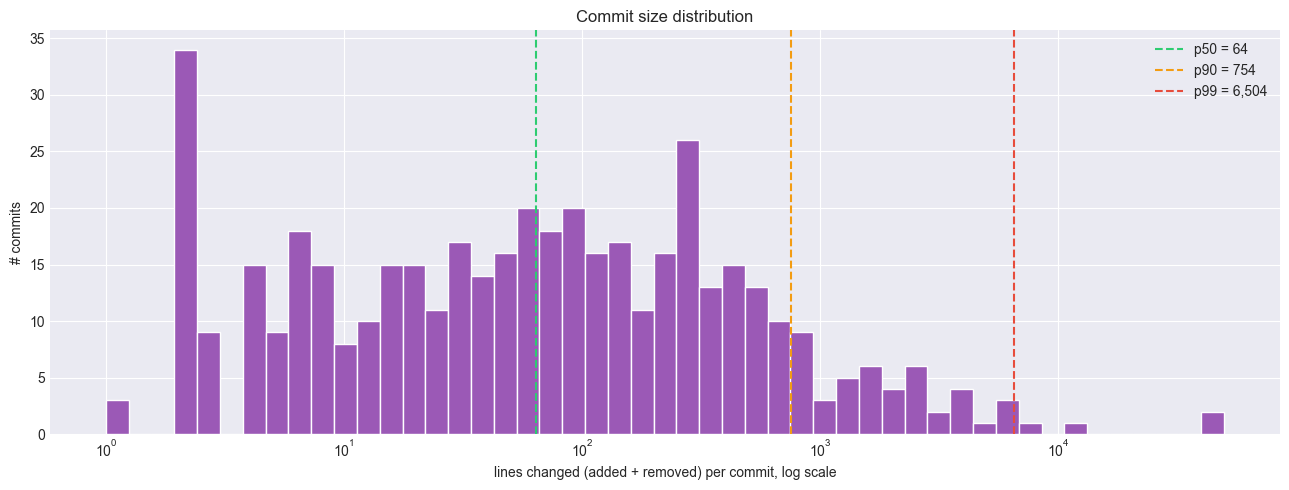

In [55]:
per_commit = df.groupby("sha")[["added","removed"]].sum()
per_commit["churn"] = per_commit["added"] + per_commit["removed"]

p50, p90, p99 = per_commit["churn"].quantile([0.5, 0.9, 0.99])
print(f"churn  p50={p50:,.0f}  p90={p90:,.0f}  p99={p99:,.0f}  max={per_commit['churn'].max():,}")

fig, ax = plt.subplots(figsize=(13, 5))
edges = np.logspace(0, np.log10(max(per_commit['churn'].max(), 10) + 1), 50)
ax.hist(per_commit["churn"], bins=edges, color="#9b59b6", edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("lines changed (added + removed) per commit, log scale")
ax.set_ylabel("# commits")
for q, name, color in [(p50, "p50", "#2ecc71"), (p90, "p90", "#f39c12"), (p99, "p99", "#e74c3c")]:
    ax.axvline(q, color=color, linestyle="--", linewidth=1.5, label=f"{name} = {q:,.0f}")
ax.legend()
ax.set_title("Commit size distribution")
fig.tight_layout()
plt.show()

## 5. Average lines added per commit, over time

If average commit size is **rising**, you're shipping bigger and bigger batches — the canonical vibes signal.

In [ ]:
commit_size = df.groupby("sha").agg(
    date=("date","first"),
    commit_idx=("commit_idx","first"),
    added=("added","sum"),
    removed=("removed","sum"),
)


def plot_commit_size_trend(x_mode="time", roll=COMMIT_ROLL):
    if x_mode == "time":
        rolling = (commit_size.set_index("date")["added"]
                     .resample(FREQ)
                     .agg(["mean", "median", "max", "count"])
                     .rename(columns={"mean":"avg", "median":"med", "count":"commits"}))
        bar_width = 5
    else:
        s = commit_size.set_index("commit_idx").sort_index()["added"]
        rolling = pd.DataFrame({
            "avg": s.rolling(roll, min_periods=1).mean(),
            "med": s.rolling(roll, min_periods=1).median(),
            "max": s.rolling(roll, min_periods=1).max(),
            "commits": pd.Series(1, index=s.index).rolling(roll, min_periods=1).sum(),
        })
        bar_width = max(1, int(len(rolling) / 200))

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax1.plot(rolling.index, rolling["avg"], label="avg added/commit", color="#e67e22", linewidth=2)
    ax1.plot(rolling.index, rolling["med"], label="median added/commit", color="#16a085", linewidth=2)
    ax1.set_ylabel("lines added per commit")
    ax2 = ax1.twinx()
    ax2.bar(rolling.index, rolling["commits"], width=bar_width, alpha=0.18, color="#7f8c8d", label="# commits")
    ax2.set_ylabel("# commits (bars)")

    suffix = f"rolling {roll} commits" if x_mode == "commits" else f"resampled {BUCKET}"
    ax1.set_title(f"Commit size trend over {x_mode} ({suffix}) — rising avg/median = bigger batches")
    _format_x_axis(ax1, x_mode)

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")
    fig.tight_layout()
    plt.show()


interact(plot_commit_size_trend,
         x_mode=Dropdown(options=["time", "commits"], value="time", description="X-axis"),
         roll=IntSlider(value=COMMIT_ROLL, min=5, max=200, step=5, description="rolling N"))

## 6. Hot files — top churn offenders

Files that keep ballooning are bloat candidates.  `net_growth` = added − removed across all history.

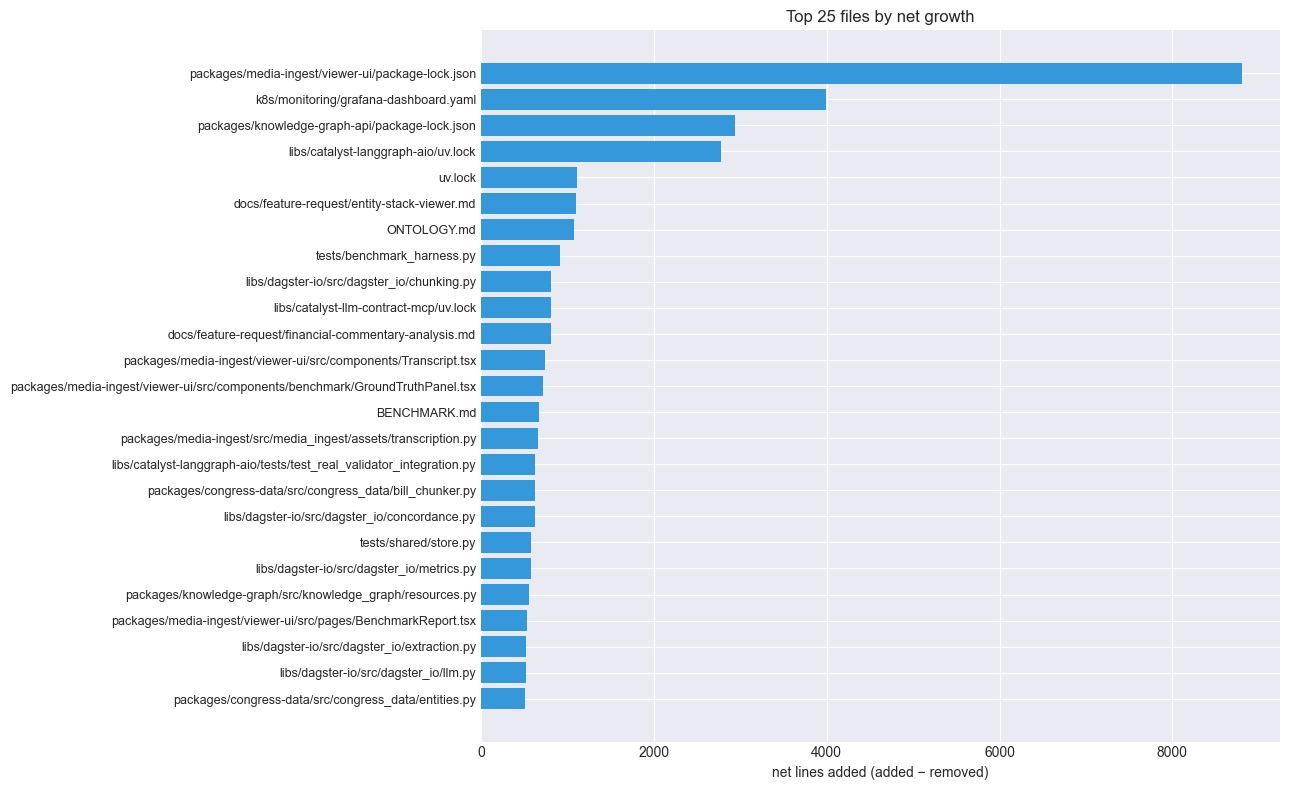

,added,removed,commits,last_touched,net_growth
path,,,,,
packages/media-ingest/viewer-ui/package-lock.json,9240,435,7,2026-04-29,8805
k8s/monitoring/grafana-dashboard.yaml,4770,779,9,2026-04-13,3991
packages/knowledge-graph-api/package-lock.json,2935,0,1,2026-04-11,2935
libs/catalyst-langgraph-aio/uv.lock,2778,1,3,2026-04-11,2777
uv.lock,1112,0,1,2026-03-16,1112
docs/feature-request/entity-stack-viewer.md,1115,15,2,2026-04-09,1100
ONTOLOGY.md,1091,9,2,2026-04-14,1082
tests/benchmark_harness.py,1150,241,12,2026-05-01,909
libs/dagster-io/src/dagster_io/chunking.py,829,16,8,2026-05-01,813


In [57]:
hot = (df.groupby("path")
         .agg(added=("added","sum"), removed=("removed","sum"),
              commits=("sha","nunique"), last_touched=("date","max"))
         .assign(net_growth=lambda d: d["added"] - d["removed"])
         .sort_values("net_growth", ascending=False)
         .head(TOP_N_FILES))

fig, ax = plt.subplots(figsize=(13, max(4, 0.32 * len(hot))))
y = np.arange(len(hot))
ax.barh(y, hot["net_growth"], color="#3498db")
ax.set_yticks(y)
ax.set_yticklabels(hot.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("net lines added (added − removed)")
ax.set_title(f"Top {TOP_N_FILES} files by net growth")
fig.tight_layout()
plt.show()
hot

## 7. Comment density — current tree

AI loves over-commenting.  This counts comment lines vs code lines per file in the current tree, then highlights the top-N most comment-heavy files (filtered to non-trivial size).  High `comment_ratio` is suspect.

In [58]:
def classify_lines(path: Path):
    """Return (code, comment, blank) for a file. Heuristic — good enough for trends."""
    ext = path.suffix.lower()
    line_cmt   = {".py":"#", ".sh":"#", ".bash":"#", ".zsh":"#", ".yaml":"#", ".yml":"#", ".toml":"#",
                  ".ts":"//", ".tsx":"//", ".js":"//", ".jsx":"//", ".mjs":"//", ".go":"//", ".rs":"//",
                  ".sql":"--"}
    block = {".py": ('"""', '"""'), ".ts": ("/*", "*/"), ".tsx": ("/*", "*/"),
             ".js": ("/*", "*/"), ".jsx": ("/*", "*/"), ".go": ("/*", "*/"), ".rs": ("/*", "*/")}
    cmt_prefix = line_cmt.get(ext)
    bs, be     = block.get(ext, (None, None))
    if cmt_prefix is None:
        return None
    code = comment = blank = 0
    in_block = False
    try:
        with open(path, "r", encoding="utf-8", errors="replace") as fh:
            for raw in fh:
                s = raw.strip()
                if not s:
                    blank += 1; continue
                if in_block:
                    comment += 1
                    if be and be in s:
                        in_block = False
                    continue
                if bs and s.startswith(bs):
                    comment += 1
                    if be and not (s.endswith(be) and len(s) > len(bs)):
                        in_block = True
                    continue
                if s.startswith(cmt_prefix):
                    comment += 1
                else:
                    code += 1
    except OSError:
        return None
    return code, comment, blank

files = [p for p in subprocess.run(["git","ls-files","-z"],capture_output=True,check=True).stdout.split(b"\x00") if p]
rows = []
for fb in files:
    p = Path(fb.decode())
    res = classify_lines(p)
    if not res:
        continue
    code, comment, blank = res
    if code + comment < 30:
        continue
    rows.append((str(p), code, comment, blank, code+comment+blank,
                 comment / max(code+comment, 1)))
comments = (pd.DataFrame(rows, columns=["path","code","comment","blank","total","comment_ratio"])
              .sort_values("comment_ratio", ascending=False))

print(f"Repo-wide:  code={comments['code'].sum():,}  comment={comments['comment'].sum():,}  "
      f"comment_ratio={comments['comment'].sum() / max(comments['code'].sum() + comments['comment'].sum(), 1):.2%}")
print(f"\nTop {TOP_N_FILES} most comment-heavy files (size ≥ 30 lines):")
comments.head(TOP_N_FILES)

Repo-wide:  code=47,479  comment=6,767  comment_ratio=12.47%

Top 25 most comment-heavy files (size ≥ 30 lines):


,path,code,comment,blank,total,comment_ratio
0,.beads/config.yaml,0,49,13,62,1.000000
5,.gitleaks.toml,17,49,10,76,0.742424
152,libs/dagster-io/src/dagster_io/versioning.py,14,21,9,44,0.600000
33,lefthook.yml,32,48,7,87,0.600000
127,libs/dagster-io/src/dagster_io/_runtime_contex...,20,28,13,61,0.583333
191,packages/congress-data/tests/test_bill_chunker.py,22,30,13,65,0.576923
51,libs/catalyst-exgraph/src/catalyst_exgraph/sta...,29,37,28,94,0.560606
321,tests/benchmark_harness.py,346,441,122,909,0.560356
315,scripts/dump_concordance.py,128,163,47,338,0.560137
149,libs/dagster-io/src/dagster_io/run_status_sens...,90,83,31,204,0.479769


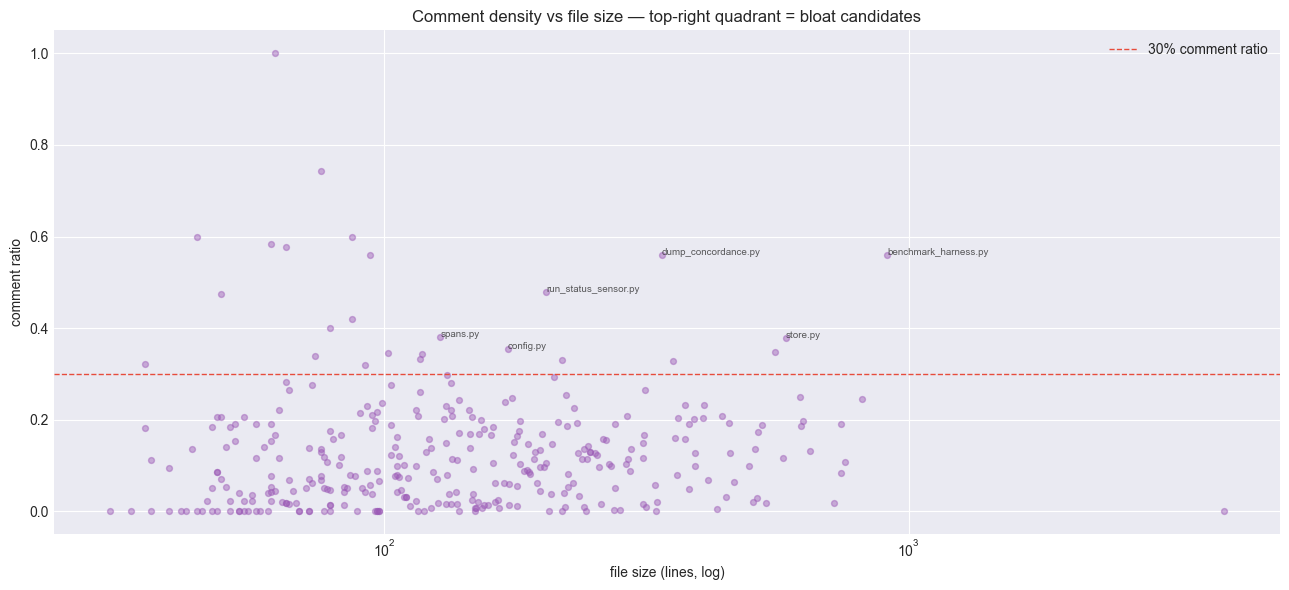

In [59]:
# Visual: comment ratio vs file size scatter, log-x.
fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(comments["total"], comments["comment_ratio"], alpha=0.45, s=18, color="#9b59b6")
ax.set_xscale("log")
ax.set_xlabel("file size (lines, log)")
ax.set_ylabel("comment ratio")
ax.set_title("Comment density vs file size — top-right quadrant = bloat candidates")
ax.axhline(0.30, color="#e74c3c", linestyle="--", linewidth=1, label="30% comment ratio")
ax.legend()
# label outliers
outliers = comments[(comments["comment_ratio"] > 0.35) & (comments["total"] > 100)].head(12)
for _, row in outliers.iterrows():
    ax.annotate(Path(row["path"]).name, (row["total"], row["comment_ratio"]),
                fontsize=7, alpha=0.75)
fig.tight_layout()
plt.show()

## 8. Test / docs / src — what's growing fastest?

AI is generous with tests and docs.  This buckets every file change by category and shows weekly net growth.

In [ ]:
def category(path: str) -> str:
    p = path.lower()
    if "/tests/" in p or p.startswith("tests/") or "/test_" in p or p.endswith("_test.go") or p.endswith(".test.ts") or p.endswith(".test.tsx"):
        return "tests"
    if p.endswith(".md") or "/docs/" in p or p.startswith("docs/"):
        return "docs"
    if p.endswith((".yaml",".yml",".toml",".json",".ini",".cfg")) or "/config/" in p:
        return "config"
    if p.endswith(".lock") or p.endswith(".lock.yaml") or "lockfile" in p:
        return "lockfiles"
    return "src"

df["category"] = df["path"].map(category)


def _cat_net_by_mode(x_mode: str) -> pd.DataFrame:
    if x_mode == "time":
        return (df.set_index("date").groupby("category")["net"]
                  .resample(FREQ).sum().unstack(level=0).fillna(0))
    return (df.groupby(["commit_idx", "category"])["net"]
              .sum().unstack("category").fillna(0).sort_index())


def plot_categories(x_mode="time"):
    cat_net = _cat_net_by_mode(x_mode)
    cat_cum = cat_net.cumsum()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for cat in cat_net.columns:
        axes[0].plot(cat_net.index, cat_net[cat], label=cat, linewidth=1.8)
        axes[1].plot(cat_cum.index, cat_cum[cat], label=cat, linewidth=2)

    period = BUCKET if x_mode == "time" else "commit"
    axes[0].set_title(f"Net lines per {period}, by category")
    axes[1].set_title("Cumulative net lines, by category")
    for ax in axes:
        ax.legend()
        ax.axhline(0, color="black", linewidth=0.5)
        _format_x_axis(ax, x_mode)
    fig.tight_layout()
    plt.show()


interact(plot_categories,
         x_mode=Dropdown(options=["time", "commits"], value="time", description="X-axis"))

summary = (df.groupby("category")
             .agg(added=("added","sum"), removed=("removed","sum"))
             .assign(net=lambda d: d["added"] - d["removed"])
             .sort_values("net", ascending=False))
summary["share_of_net"] = summary["net"] / summary["net"].sum()
summary.style.format({"added":"{:,}", "removed":"{:,}", "net":"{:+,}", "share_of_net":"{:.1%}"})

## 9. Bloat scorecard

Heuristic combined score per file:

- size (lines) — bigger files look more bloat-prone
- comment_ratio — high = AI-style verbosity
- net_growth — file keeps swelling commit after commit
- recent_churn — touched recently, so still in flux

Each is min-max normalized and summed.  Use as a **starting point for review**, not gospel.

In [61]:
recent_cutoff = df["date"].max() - pd.Timedelta(days=30)
recent = (df[df["date"] >= recent_cutoff].groupby("path")["added"].sum().rename("recent_added"))

scorecard = (comments.set_index("path")
             .join(hot[["net_growth", "commits"]], how="left")
             .join(recent, how="left")
             .fillna(0))

def norm(s):
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

scorecard["bloat_score"] = (
    norm(scorecard["total"]) * 0.25 +
    norm(scorecard["comment_ratio"]) * 0.25 +
    norm(scorecard["net_growth"].clip(lower=0)) * 0.30 +
    norm(scorecard["recent_added"]) * 0.20
)

scorecard.sort_values("bloat_score", ascending=False).head(TOP_N_FILES)[
    ["total", "comment_ratio", "net_growth", "commits", "recent_added", "bloat_score"]
].style.format({
    "total":"{:,}", "comment_ratio":"{:.0%}", "net_growth":"{:+,}",
    "commits":"{:.0f}", "recent_added":"{:,.0f}", "bloat_score":"{:.3f}",
}).background_gradient(subset=["bloat_score"], cmap="Reds")

,total,comment_ratio,net_growth,commits,recent_added,bloat_score
path,,,,,,
k8s/monitoring/grafana-dashboard.yaml,"3,991",0%,"+3,991.0",9,"3,741",0.750
tests/benchmark_harness.py,909,56%,+909.0,12,"1,150",0.325
.beads/config.yaml,62,100%,+0.0,0,0,0.252
tests/shared/store.py,583,38%,+583.0,7,767,0.214
libs/dagster-io/src/dagster_io/chunking.py,813,25%,+813.0,8,606,0.204
packages/media-ingest/src/media_ingest/assets/transcription.py,742,19%,+662.0,25,"1,151",0.204
.gitleaks.toml,76,74%,+0.0,0,76,0.193
packages/knowledge-graph/src/knowledge_graph/resources.py,556,35%,+556.0,9,401,0.183
scripts/dump_concordance.py,338,56%,+0.0,0,442,0.183


## 10. Code structure metrics — complexity, interfaces, coverage

Three new layers of signal beyond raw line stats:

- **Cyclomatic complexity (McCabe)** per Python function — `cc_max` and `cc_mean` per file. Pure stdlib `ast` walk, no `radon` dependency.
- **Interface shape** — public function/class counts, max class method count, max parameter count, **fan-out / fan-in / instability** (Martin's `I = Ce / (Ce + Ca)`).
- **Coverage** — auto-loaded from any `coverage.xml` (cobertura) found in the tree. Both line and branch rates. Skipped gracefully if no coverage report exists.

These feed a separate `messiness_score` (different from `bloat_score`) that flags wide / tangled / under-tested files.

In [ ]:
import ast
from collections import defaultdict

# ── Cyclomatic complexity (McCabe) — pure ast, no third-party dep ───────
_DECISION_NODES = (
    ast.If, ast.For, ast.AsyncFor, ast.While,
    ast.ExceptHandler, ast.IfExp, ast.comprehension,
)
try:
    _DECISION_NODES = _DECISION_NODES + (ast.match_case,)  # py3.10+
except AttributeError:
    pass

def cc_of_function(node: ast.AST) -> int:
    cc = 1
    for child in ast.walk(node):
        if isinstance(child, _DECISION_NODES):
            cc += 1
        elif isinstance(child, ast.BoolOp):
            cc += max(0, len(child.values) - 1)
    return cc

# ── Module map (file -> dotted module) so we can resolve internal imports
def _path_to_module(path: str) -> str | None:
    p = path.replace("\\", "/")
    if not p.endswith(".py"):
        return None
    parts = p[:-3].split("/")
    # strip common src-layout prefixes
    cleaned = [seg for seg in parts if seg not in ("src", "lib", "libs")]
    return ".".join(cleaned) if cleaned else None

py_files = [Path(f.decode()) for f in
            subprocess.run(["git","ls-files","-z"], capture_output=True, check=True)
              .stdout.split(b"\x00")
            if f and f.decode().endswith(".py")]

module_to_path: dict[str, str] = {}
for p in py_files:
    mod = _path_to_module(str(p))
    if mod:
        module_to_path[mod] = str(p)

# Top-level package roots for "internal" detection
internal_roots = set()
for mod in module_to_path:
    head = mod.split(".", 1)[0]
    if head:
        internal_roots.add(head)

def _is_internal_import(module: str) -> bool:
    if not module:
        return False
    head = module.split(".", 1)[0]
    return head in internal_roots

# ── Walk every py file once: complexity + interface + imports ──────────
metric_rows = []
fan_out_edges: dict[str, set[str]] = defaultdict(set)  # importer_path -> {imported_path}

for path in py_files:
    try:
        src = path.read_text(encoding="utf-8", errors="replace")
        tree = ast.parse(src, filename=str(path))
    except (SyntaxError, OSError):
        continue

    # complexity over every function-like node
    func_ccs: list[int] = []
    max_params = 0
    for node in ast.walk(tree):
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            func_ccs.append(cc_of_function(node))
            max_params = max(max_params, len(node.args.args) + len(node.args.kwonlyargs))

    # public surface
    public_funcs = sum(
        1 for n in tree.body
        if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef)) and not n.name.startswith("_")
    )
    classes = [n for n in tree.body if isinstance(n, ast.ClassDef)]
    public_classes = sum(1 for c in classes if not c.name.startswith("_"))
    max_class_methods = max(
        (sum(1 for cn in c.body if isinstance(cn, (ast.FunctionDef, ast.AsyncFunctionDef)))
         for c in classes),
        default=0,
    )

    # imports → fan-out (internal only)
    importer = str(path)
    for node in ast.walk(tree):
        if isinstance(node, ast.Import):
            for alias in node.names:
                if _is_internal_import(alias.name):
                    target = module_to_path.get(alias.name)
                    if target and target != importer:
                        fan_out_edges[importer].add(target)
        elif isinstance(node, ast.ImportFrom):
            mod = node.module or ""
            if _is_internal_import(mod):
                target = module_to_path.get(mod)
                if target and target != importer:
                    fan_out_edges[importer].add(target)

    metric_rows.append({
        "path": str(path),
        "cc_max":  max(func_ccs, default=0),
        "cc_mean": (sum(func_ccs) / len(func_ccs)) if func_ccs else 0.0,
        "func_count": len(func_ccs),
        "public_funcs":   public_funcs,
        "public_classes": public_classes,
        "max_class_methods": max_class_methods,
        "max_func_params":   max_params,
    })

metrics = pd.DataFrame(metric_rows).set_index("path")

# fan-in via reversed edge map
fan_in_count: dict[str, int] = defaultdict(int)
for importer, targets in fan_out_edges.items():
    for t in targets:
        fan_in_count[t] += 1

metrics["fan_out"] = metrics.index.map(lambda p: len(fan_out_edges.get(p, ())))
metrics["fan_in"]  = metrics.index.map(lambda p: fan_in_count.get(p, 0))
metrics["instability"] = metrics.apply(
    lambda r: (r["fan_out"] / (r["fan_in"] + r["fan_out"])) if (r["fan_in"] + r["fan_out"]) > 0 else 0.0,
    axis=1,
)

print(f"Analyzed {len(metrics):,} python files  "
      f"(internal package roots: {sorted(internal_roots)[:8]}{'…' if len(internal_roots) > 8 else ''})")
print(f"\n=== Worst by cc_max ===")
print(metrics.sort_values("cc_max", ascending=False).head(15)
        [["cc_max","cc_mean","func_count","fan_out","fan_in","instability"]]
        .round(2).to_string())
print(f"\n=== Most unstable (fan_out / (fan_in + fan_out)) ===")
print(metrics[(metrics["fan_in"] + metrics["fan_out"]) >= 3]
        .sort_values("instability", ascending=False).head(15)
        [["fan_in","fan_out","instability","public_funcs","public_classes"]]
        .round(2).to_string())


In [ ]:
import xml.etree.ElementTree as ET

# ── Coverage (cobertura coverage.xml) — graceful no-op if absent ────────
def _find_coverage_xml() -> list[Path]:
    candidates = []
    root = Path(REPO_ROOT)
    for p in root.glob("coverage.xml"):
        candidates.append(p)
    for p in root.glob("**/coverage.xml"):
        # skip nested venvs / node_modules / build dirs
        s = str(p)
        if any(seg in s for seg in ("node_modules", ".venv", "venv/", ".tox", "site-packages")):
            continue
        candidates.append(p)
    # de-dupe while preserving order
    seen = set()
    out = []
    for p in candidates:
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            out.append(p)
    return out

def _parse_cobertura(path: Path) -> pd.DataFrame:
    """Cobertura-style XML → DataFrame[path, line_rate, branch_rate]."""
    tree = ET.parse(path)
    root = tree.getroot()
    sources = [s.text for s in root.iter("source") if s.text]
    rows = []
    for cls in root.iter("class"):
        fname = cls.get("filename") or ""
        # Try absolute → repo-relative
        candidates = [fname] + [str(Path(s) / fname) for s in sources]
        rel = None
        for c in candidates:
            ap = Path(c)
            if not ap.is_absolute():
                ap = (Path(path).parent / c).resolve()
            try:
                rel = str(ap.relative_to(Path(REPO_ROOT)))
                break
            except ValueError:
                continue
        rel = rel or fname
        rows.append({
            "path":        rel,
            "line_rate":   float(cls.get("line-rate") or 0),
            "branch_rate": float(cls.get("branch-rate") or 0),
        })
    return pd.DataFrame(rows)

cov_files = _find_coverage_xml()
if cov_files:
    parts = []
    for cf in cov_files:
        try:
            parts.append(_parse_cobertura(cf))
        except ET.ParseError as exc:
            print(f"  skip {cf}: {exc}")
    coverage = (pd.concat(parts, ignore_index=True)
                  .groupby("path", as_index=False)
                  .agg(line_rate=("line_rate","max"),
                       branch_rate=("branch_rate","max"))
                  .set_index("path"))
    print(f"Loaded coverage for {len(coverage):,} files from {len(cov_files)} report(s):")
    for cf in cov_files:
        print(f"  - {cf.relative_to(REPO_ROOT)}")
    print(f"\nOverall line coverage:   {coverage['line_rate'].mean():.1%}")
    print(f"Overall branch coverage: {coverage['branch_rate'].mean():.1%}")
else:
    coverage = pd.DataFrame(columns=["line_rate","branch_rate"])
    coverage.index.name = "path"
    print("No coverage.xml found — skipping coverage. Generate one with e.g.:")
    print("  poetry run pytest --cov --cov-report=xml")


In [ ]:
# ── Messiness score — different from bloat_score, focuses on structure ─
quality = (metrics
           .join(coverage, how="left")
           .fillna({"line_rate": 0.0, "branch_rate": 0.0}))

def _norm(s):
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

quality["uncovered_line"]   = 1.0 - quality["line_rate"]
quality["uncovered_branch"] = 1.0 - quality["branch_rate"]

quality["messiness_score"] = (
    _norm(quality["cc_max"].clip(lower=0))            * 0.25 +
    _norm(quality["cc_mean"].clip(lower=0))           * 0.15 +
    _norm(quality["instability"])                     * 0.20 +
    _norm(quality["public_funcs"].astype(float))      * 0.10 +
    _norm(quality["max_func_params"].astype(float))   * 0.10 +
    _norm(quality["uncovered_line"])                  * 0.20
)

# Display worst offenders
top_messy = (quality.sort_values("messiness_score", ascending=False)
                    .head(TOP_N_FILES))

display_cols = ["cc_max","cc_mean","public_funcs","public_classes",
                "max_class_methods","max_func_params",
                "fan_in","fan_out","instability",
                "line_rate","branch_rate","messiness_score"]

styled = top_messy[display_cols].style.format({
    "cc_max":            "{:.0f}",
    "cc_mean":           "{:.1f}",
    "public_funcs":      "{:.0f}",
    "public_classes":    "{:.0f}",
    "max_class_methods": "{:.0f}",
    "max_func_params":   "{:.0f}",
    "fan_in":            "{:.0f}",
    "fan_out":           "{:.0f}",
    "instability":       "{:.2f}",
    "line_rate":         "{:.0%}",
    "branch_rate":       "{:.0%}",
    "messiness_score":   "{:.3f}",
}).background_gradient(subset=["messiness_score"], cmap="Purples")

# Also fold messiness back into the bloat scorecard for the aggregate report
scorecard = scorecard.join(
    quality[["cc_max","cc_mean","instability","fan_in","fan_out",
             "public_funcs","line_rate","branch_rate","messiness_score"]],
    how="left",
).fillna({
    "cc_max":0, "cc_mean":0, "instability":0, "fan_in":0, "fan_out":0,
    "public_funcs":0, "line_rate":0, "branch_rate":0, "messiness_score":0,
})

styled


## 11. Aggregate report + AI remediation prompt

Pulls every dataframe above (commit history, line stats, comment density, hot files, bloat scorecard, **plus the new complexity / interface / coverage layer**) into a single structured report (`bloat_report.json` + inline markdown digest), then emits a self-contained prompt for another AI agent.

The prompt explicitly instructs the downstream agent to use the **`codebase-memory` MCP knowledge-graph tools** (`search_graph`, `trace_call_path`, `query_graph`, `get_architecture`) to verify duplication / DRY violations / dead code / **messy interfaces** at the structural level — the statistical signals from earlier cells are only used as a *prioritization* layer.

**Hard rule baked into the prompt: NO loss of functionality.** The downstream agent may only propose merges, dedup, comment trims, dead-symbol removal, abstraction collapses, and **interface narrowing behind deprecation shims** — never feature/API removal.

In [ ]:
import json

# ── 1. Aggregate everything in-memory into a single structured report ────
TOP_N_REPORT = 30   # entries per ranked list embedded in the report/prompt

aggregated_report = {
    "repo_root": REPO_ROOT,
    "generated_at": pd.Timestamp.utcnow().isoformat(),
    "config": {
        "since": SINCE,
        "bucket": BUCKET,
        "pathspec": PATHSPEC,
        "top_n_files": TOP_N_FILES,
    },
    "summary": {
        "commits":              int(df["sha"].nunique()),
        "file_changes":         int(len(df)),
        "first_commit":         df["date"].min().date().isoformat(),
        "last_commit":          df["date"].max().date().isoformat(),
        "added":                int(df["added"].sum()),
        "removed":              int(df["removed"].sum()),
        "net":                  int(df["net"].sum()),
        "current_total_lines":  int(current_total),
        "code_comment_ratio_overall": float(
            comments["comment"].sum() /
            max(comments["code"].sum() + comments["comment"].sum(), 1)
        ),
        "commit_churn_p50":     float(p50),
        "commit_churn_p90":     float(p90),
        "commit_churn_p99":     float(p99),
        "commit_churn_max":     int(per_commit["churn"].max()),
        "py_files_analyzed":    int(len(metrics)),
        "overall_line_coverage":   float(coverage["line_rate"].mean())   if len(coverage)   else None,
        "overall_branch_coverage": float(coverage["branch_rate"].mean()) if len(coverage)   else None,
    },
    "lines_by_language": {k: int(v) for k, v in current_by_lang.items()},
    "lines_by_bucket":   {k: int(v) for k, v in (current_by_bucket or {}).items()},
    "category_summary":  summary.reset_index().to_dict(orient="records"),
    "top_hot_files":     hot.reset_index().head(TOP_N_REPORT).to_dict(orient="records"),
    "top_comment_heavy_files":
        comments.head(TOP_N_REPORT).to_dict(orient="records"),
    "top_bloat_scorecard": (
        scorecard.sort_values("bloat_score", ascending=False)
                 .head(TOP_N_REPORT)
                 .reset_index()
                 [["path", "total", "comment_ratio", "net_growth",
                   "commits", "recent_added", "bloat_score"]]
                 .to_dict(orient="records")
    ),
    "top_messy_interfaces": (
        quality.sort_values("messiness_score", ascending=False)
               .head(TOP_N_REPORT)
               .reset_index()
               [["path","cc_max","cc_mean","public_funcs","public_classes",
                 "max_class_methods","max_func_params","fan_in","fan_out",
                 "instability","line_rate","branch_rate","messiness_score"]]
               .to_dict(orient="records")
    ),
    "top_complex_functions": (
        metrics.sort_values("cc_max", ascending=False)
               .head(TOP_N_REPORT)
               .reset_index()
               [["path","cc_max","cc_mean","func_count","max_func_params"]]
               .to_dict(orient="records")
    ),
    "top_unstable_modules": (
        quality[(quality["fan_in"] + quality["fan_out"]) >= 3]
               .sort_values("instability", ascending=False)
               .head(TOP_N_REPORT)
               .reset_index()
               [["path","fan_in","fan_out","instability",
                 "public_funcs","public_classes"]]
               .to_dict(orient="records")
    ),
    "lowest_coverage_files": (
        (coverage.sort_values("line_rate", ascending=True)
                 .head(TOP_N_REPORT)
                 .reset_index()
                 [["path","line_rate","branch_rate"]]
                 .to_dict(orient="records"))
        if len(coverage) else []
    ),
}

REPORT_DIR = Path(REPO_ROOT) / "scripts" / "analysis" / "repo_stats_out"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
report_path = REPORT_DIR / "bloat_report.json"
report_path.write_text(json.dumps(aggregated_report, indent=2, default=str))
print(f"Wrote {report_path}  ({report_path.stat().st_size:,} bytes)")

# Compact markdown digest for quick eyeballing inline
def _md_table(records, cols, fmts):
    out = ["| " + " | ".join(cols) + " |",
           "|" + "|".join(["---"] * len(cols)) + "|"]
    for r in records:
        out.append("| " + " | ".join(fmts[c](r.get(c, "")) for c in cols) + " |")
    return "\n".join(out)

print("\n### Bloat scorecard — top 15\n")
print(_md_table(
    aggregated_report["top_bloat_scorecard"][:15],
    ["path", "total", "comment_ratio", "net_growth", "commits", "bloat_score"],
    fmts={
        "path":          str,
        "total":         lambda v: f"{int(v):,}",
        "comment_ratio": lambda v: f"{float(v):.0%}",
        "net_growth":    lambda v: f"{int(v):+,}",
        "commits":       lambda v: f"{int(v)}",
        "bloat_score":   lambda v: f"{float(v):.3f}",
    },
))
print("\n### Messiness scorecard — top 15\n")
print(_md_table(
    aggregated_report["top_messy_interfaces"][:15],
    ["path","cc_max","cc_mean","fan_in","fan_out","instability",
     "line_rate","messiness_score"],
    fmts={
        "path":            str,
        "cc_max":          lambda v: f"{int(v)}",
        "cc_mean":         lambda v: f"{float(v):.1f}",
        "fan_in":          lambda v: f"{int(v)}",
        "fan_out":         lambda v: f"{int(v)}",
        "instability":     lambda v: f"{float(v):.2f}",
        "line_rate":       lambda v: f"{float(v):.0%}",
        "messiness_score": lambda v: f"{float(v):.3f}",
    },
))

In [ ]:
import json
from textwrap import dedent

# ── 2. Build the AI remediation prompt ───────────────────────────────────
# Embeds the stats above + explicit instructions to use codebase-memory MCP
# tools (the structural knowledge graph) to verify any DRY / dead-code /
# messy-interface claim.

PROMPT = dedent(f"""\
# Codebase Remediation Analysis — `catalyst-data`

You are an expert reviewer auditing the **catalyst-data** monorepo for
bloat, DRY violations, **and messy interfaces**. This task is a follow-up
to a heuristic statistical pass (commits, churn, comment density, hot
files, bloat scorecard, cyclomatic complexity, fan-in/fan-out instability,
and coverage). Your job is the *structural* layer: cross-reference these
signals against the actual code graph and surface concrete, reviewable
remediation opportunities.

## HARD CONSTRAINT — NO FUNCTIONALITY LOSS

Every suggestion MUST preserve the **observable behavior** of the codebase.

ALLOWED:
- Merge duplicate / near-duplicate functions or classes
- Extract shared logic into a helper or base class
- Remove dead code (unreferenced public symbols, unreachable branches)
- Trim low-value AI-generated comments (paraphrase-of-code, not WHY)
- Collapse redundant abstractions (one-line wrappers, single-use indirections)
- Replace copy-pasted blocks with calls to an existing equivalent
- **Narrow over-wide interfaces** (split god-classes, reduce parameter lists
  via dataclasses, extract sub-modules) — but keep the public surface
  reachable through a deprecation shim if anything outside this repo imports it

NOT ALLOWED:
- Removing features, endpoints, CLI flags, env vars, public API surface
- Loosening validation/error handling at external boundaries
- Behavior changes disguised as refactors

## REQUIRED TOOLING — `codebase-memory` MCP (knowledge graph)

This repo is indexed in the `codebase-memory` MCP server. Before drafting
any remediation, you MUST use these tools to verify your hypotheses are
real (not just statistical artifacts):

- `mcp__codebase-memory__list_projects` — confirm the repo is indexed
- `mcp__codebase-memory__get_architecture` — orient on package layout
- `mcp__codebase-memory__get_graph_schema` — see node/edge types available
- `mcp__codebase-memory__search_graph` — find a function/class by name
  across packages (look for near-duplicates by name: multiple `parse_chunk`,
  `load_config`, `norm`, `classify`, `to_records`, etc.)
- `mcp__codebase-memory__query_graph` — Cypher-like queries. Examples:

    ```
    // ── Duplication ──────────────────────────────────────────────
    // Function names defined more than once across the repo
    MATCH (f:Function) WITH f.name AS name, count(*) AS c
    WHERE c > 1 RETURN name, c ORDER BY c DESC

    // ── Dead code ────────────────────────────────────────────────
    // Functions never called by any other function
    MATCH (f:Function) WHERE NOT (()-[:CALLS]->(f))
    RETURN f.name, f.file LIMIT 50

    // ── Messy / wide interfaces ──────────────────────────────────
    // Functions with very wide parameter lists
    MATCH (f:Function) WHERE size(f.params) > 8
    RETURN f.file, f.name, size(f.params) AS arity ORDER BY arity DESC LIMIT 30

    // Classes with too many methods (god-class smell)
    MATCH (c:Class)-[:HAS_METHOD]->(m:Function)
    WITH c, count(m) AS method_count
    WHERE method_count > 15
    RETURN c.file, c.name, method_count ORDER BY method_count DESC LIMIT 20

    // Modules with high afferent coupling (everyone depends on them — risky)
    MATCH (m:Module)<-[:IMPORTS]-(other:Module)
    WITH m, count(DISTINCT other) AS afferent
    WHERE afferent > 10
    RETURN m.path, afferent ORDER BY afferent DESC LIMIT 20

    // Modules with high efferent coupling (depend on too many things)
    MATCH (m:Module)-[:IMPORTS]->(other:Module)
    WITH m, count(DISTINCT other) AS efferent
    WHERE efferent > 15
    RETURN m.path, efferent ORDER BY efferent DESC LIMIT 20
    ```
- `mcp__codebase-memory__trace_call_path` — confirm a candidate dead
  function truly has no inbound edges
- `mcp__codebase-memory__search_code` — semantic snippet lookup (graph)
- `mcp__codebase-memory__get_code_snippet` — pull the actual source for a
  symbol before recommending a change

`mcp__claude-context__search_code` is also available for semantic search
across the same repo when a graph query comes up empty.

## STATISTICAL SIGNALS (from `scripts/repo_stats.ipynb`)

Use these as a **prioritization layer** — investigate top entries first,
since they combine size, comment density, churn, recency, complexity,
instability, and coverage gaps.

### Repo summary
```json
{json.dumps(aggregated_report["summary"], indent=2, default=str)}
```

### Lines by language
```json
{json.dumps(aggregated_report["lines_by_language"], indent=2)}
```

### Lines by bucket (code / tests / fixtures)
```json
{json.dumps(aggregated_report["lines_by_bucket"], indent=2)}
```

### Category net-growth share
```json
{json.dumps(aggregated_report["category_summary"], indent=2, default=str)}
```

### Top files by net growth (added − removed)
```json
{json.dumps(aggregated_report["top_hot_files"][:20], indent=2, default=str)}
```

### Top comment-heavy files
```json
{json.dumps(aggregated_report["top_comment_heavy_files"][:20], indent=2, default=str)}
```

### Top bloat scorecard (combined heuristic)
```json
{json.dumps(aggregated_report["top_bloat_scorecard"][:20], indent=2, default=str)}
```

### Top messy interfaces (cyclomatic + fan-in/out + coverage)
```json
{json.dumps(aggregated_report["top_messy_interfaces"][:20], indent=2, default=str)}
```

### Most-complex files (cc_max)
```json
{json.dumps(aggregated_report["top_complex_functions"][:20], indent=2, default=str)}
```

### Most-unstable modules (Martin's I = fan_out / (fan_in + fan_out))
```json
{json.dumps(aggregated_report["top_unstable_modules"][:20], indent=2, default=str)}
```

### Lowest-coverage files
```json
{json.dumps(aggregated_report["lowest_coverage_files"][:20], indent=2, default=str)}
```

## DELIVERABLE

Produce a single markdown report titled **Bloat & Messiness Remediation
Plan** with:

1. **Executive summary** — one paragraph, ≤ 5 bullets of headline findings.

2. **Duplication map** — for each cluster of duplicated logic, list:
   - canonical path you'd keep
   - duplicate(s) you'd remove or fold in
   - concrete shared abstraction (function name + signature)
   - estimated LOC saved
   - the codebase-memory query you used to confirm the duplication

3. **Dead-code candidates** — symbols with no inbound `CALLS` / `REFERENCES`
   edges. Format: `path:line — symbol — confidence (why)`. Always include
   the `query_graph` Cypher or `trace_call_path` trace that justifies it.

4. **Messy interface diagnoses** — for each file in the top messiness list:
   - what makes it messy (high cc, wide params, god-class, high instability)
   - the codebase-memory query that confirms it
   - concrete narrowing suggestion (split / dataclass / sub-module / shim)
   - ALWAYS preserve external API: name the deprecation shim if needed

5. **Comment-bloat trim list** — files where comment density > 30% AND
   the comments paraphrase code rather than encode non-obvious WHY. Quote
   2–3 example blocks per file.

6. **Abstraction collapses** — wrapper functions, single-use config
   indirections, premature-generic helpers that can fold inline without
   losing testability.

7. **Coverage-driven priorities** — files in the lowest-coverage list that
   you'd want covered *before* refactoring. Note any low-coverage file you
   intend to refactor and propose the regression-pinning tests first.

8. **Out of scope / risky** — things that *look* like bloat or messiness
   from the stats but are load-bearing (test fixtures, generated code,
   intentional verbosity in security-critical paths, integration boundaries
   that must stay unstable). Be explicit about what you investigated and
   decided NOT to touch, and why.

9. **Suggested PR slicing** — group remediations into 3–6 reviewable PRs,
   ordered by risk (lowest first). For each, list touched files and a
   one-line summary.

For EVERY concrete suggestion, include `file:line` references AND the
codebase-memory tool call (or query) that justifies it. Suggestions
without graph-level evidence are not acceptable.

**Begin** by calling `mcp__codebase-memory__list_projects` and
`mcp__codebase-memory__get_architecture`, then proceed.
""")

prompt_path = REPORT_DIR / "bloat_analysis_prompt.md"
prompt_path.write_text(PROMPT)

print(f"Wrote {prompt_path}  ({len(PROMPT):,} chars)")
print("\n--- prompt preview (first 50 lines) ---\n")
print("\n".join(PROMPT.splitlines()[:50]))
print("\n[...]\n")
print(f"Full prompt at: {prompt_path}")
